<div style="background:linear-gradient(135deg,#78350f 0%,#b45309 55%,#f59e0b 100%);border-radius:18px;padding:32px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#fde68a;font-weight:700;text-transform:uppercase">Chapter 162 &middot; Capstone 3 &middot; Paired t-Test</div>
  <div style="font-size:32px;font-weight:900;line-height:1.1;margin:10px 0 6px">Did the Program Lower Blood Pressure?</div>
  <div style="font-size:15px;color:#fef3c7;max-width:780px;line-height:1.6">The same patients, measured before and after an eight-week program. Because each person is measured twice, we compare each patient to themselves, and analyze the within-person change. A full framework pass on a paired design, ending with the one question the test cannot answer on its own.</div>
</div>

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import pingouin as pg
plt.rcParams.update({"figure.dpi":110,"font.size":11,"axes.spines.top":False,"axes.spines.right":False,
    "axes.grid":True,"grid.alpha":0.22,"axes.titleweight":"bold","axes.titlesize":12.5,"axes.titlelocation":"left"})
GOLD, AMBER, DARK, BL, RD, GR, MUT = "#b45309", "#d97706", "#78350f", "#2563eb", "#dc2626", "#16a34a", "#94a3b8"

BASE = "https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
fn = "capstone-blood-pressure-before-after.xlsx"
try: raw = pd.read_excel("../../data/" + fn, sheet_name="bp")
except FileNotFoundError: raw = pd.read_excel(BASE + fn, sheet_name="bp")
print("loaded", raw.shape[0], "rows")
raw.head()

loaded 64 rows


,patient_id,age,sbp_before,sbp_after
0,P100,69,137,131.0
1,P101,47,144,140.0
2,P102,50,159,142.0
3,P103,52,155,135.0
4,P104,50,149,141.0


## Step 1 &middot; Goal and hypotheses
A clinic put hypertensive patients through an eight-week program and measured each person's systolic blood pressure before it started and again at the end. Because every patient contributes a before and an after, this is a **paired** design, and the natural quantity to study is each patient's **change**.

We test whether the average change is zero.
- **H&#8320; (null):** the mean systolic BP is the same before and after (mean change = 0).
- **H&#8321; (alternative):** the mean changes.
- **&#945; = 0.05**, two-sided.

## Step 2 &middot; Know the data types
Two **continuous** measurements per patient, `sbp_before` and `sbp_after` (mmHg), linked by `patient_id`. The key is that the two columns are not two independent groups: they are the same people twice. That pairing is what makes this a paired t-test rather than a two-sample one.

In [2]:
print(raw.dtypes)
print("\ntwo readings per patient (before, after)  ->  paired design  ->  analyze the differences")

patient_id        str
age             int64
sbp_before      int64
sbp_after     float64
dtype: object

two readings per patient (before, after)  ->  paired design  ->  analyze the differences


## Step 3 &middot; Describe
Look at the before and after readings, and the number of patients. The two columns overlap heavily, which is expected: the same people, eight weeks apart.

In [3]:
print("rows:", len(raw), " unique patients:", raw.patient_id.nunique())
print("\nbefore/after summary (raw):")
print(raw[["sbp_before","sbp_after"]].describe().round(1).to_string())

rows: 64  unique patients: 62

before/after summary (raw):
       sbp_before  sbp_after
count        64.0       60.0
mean        145.1      139.2
std          19.0       31.1
min          29.0        0.0
25%         137.8      127.0
50%         148.5      139.5
75%         156.0      146.2
max         168.0      300.0


## Step 4 &middot; Visualize first
For paired data the right first picture is a **paired plot**: one line per patient from their before value to their after value. A downward slope means that patient improved. Alongside it, the distribution of the differences, which is what the test actually uses.

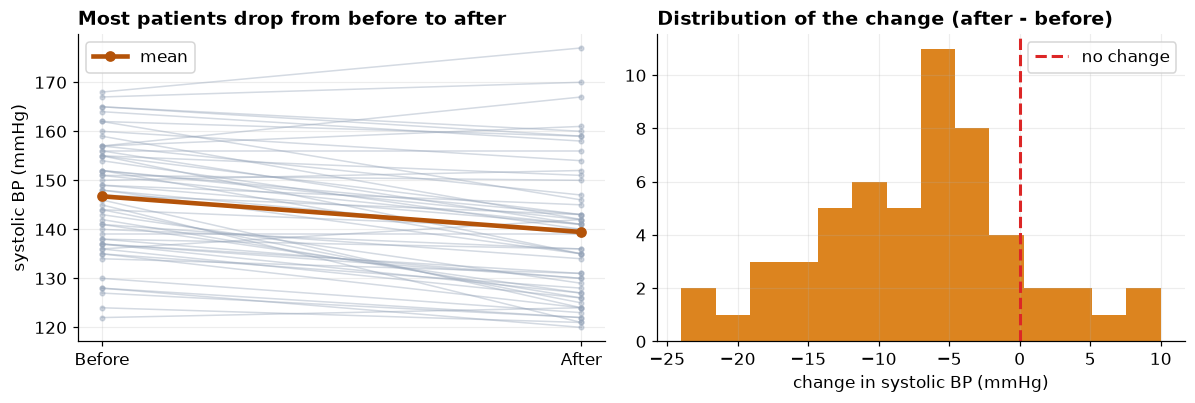

In [4]:
tmp = raw.drop_duplicates().dropna(subset=["sbp_before","sbp_after"])
tmp = tmp[(tmp.sbp_before.between(70,250)) & (tmp.sbp_after.between(70,250))]
fig, ax = plt.subplots(1, 2, figsize=(11, 3.8))
for _, r in tmp.iterrows():
    ax[0].plot([0,1], [r.sbp_before, r.sbp_after], color=MUT, alpha=0.4, lw=1, marker="o", markersize=3)
ax[0].plot([0,1], [tmp.sbp_before.mean(), tmp.sbp_after.mean()], color=GOLD, lw=3, marker="o", label="mean")
ax[0].set_xticks([0,1]); ax[0].set_xticklabels(["Before","After"]); ax[0].set_ylabel("systolic BP (mmHg)")
ax[0].set_title("Most patients drop from before to after"); ax[0].legend()
diff = (tmp.sbp_after - tmp.sbp_before).values
ax[1].hist(diff, bins=14, color=AMBER, alpha=0.9)
ax[1].axvline(0, color=RD, lw=2, ls="--", label="no change")
ax[1].set_title("Distribution of the change (after - before)"); ax[1].set_xlabel("change in systolic BP (mmHg)"); ax[1].legend()
plt.tight_layout(); plt.show()

## Step 5 &middot; Prepare and clean
A paired analysis needs **both** readings for a patient, so anyone missing a follow-up cannot be used. Clean in order: drop **duplicate rows**, drop patients missing either reading (the **dropouts**), and drop **impossible values** (a real systolic BP sits between 70 and 250 mmHg, so a 0, a 29, and a 300 all go).

In [5]:
df = raw.drop_duplicates(); after_dup = len(df)
df = df.dropna(subset=["sbp_before","sbp_after"]); after_na = len(df)
inrange = df.sbp_before.between(70,250) & df.sbp_after.between(70,250)
bad = df[~inrange]
df = df[inrange].copy()
print(f"start {len(raw)}  ->  dedup {after_dup} (-{len(raw)-after_dup})  ->  both readings {after_na} (-{after_dup-after_na} dropouts)  ->  in-range {len(df)} (-{after_na-len(df)})")
print("impossible readings removed:", sorted(pd.concat([bad.sbp_before, bad.sbp_after]).loc[lambda s: (s<70)|(s>250)].tolist()))
print(f"clean paired sample: n = {len(df)} patients")

start 64  ->  dedup 62 (-2)  ->  both readings 58 (-4 dropouts)  ->  in-range 55 (-3)
impossible readings removed: [0.0, 29.0, 300.0]
clean paired sample: n = 55 patients


In [6]:
before = df.sbp_before.values.astype(float)
after  = df.sbp_after.values.astype(float)
change = after - before
print(f"before: mean {before.mean():.1f}  sd {before.std(ddof=1):.1f}")
print(f"after : mean {after.mean():.1f}  sd {after.std(ddof=1):.1f}")
print(f"change: mean {change.mean():+.2f}  sd {change.std(ddof=1):.2f} mmHg")
print(f"correlation between before and after: r = {np.corrcoef(before, after)[0,1]:.2f}  (high, because it is the same people)")

before: mean 146.7  sd 11.7
after : mean 139.5  sd 13.9
change: mean -7.27  sd 7.32 mmHg
correlation between before and after: r = 0.85  (high, because it is the same people)


## Step 6 &middot; Name the design, and why it matters
This is a **paired** (within-subject) design: each patient is their own comparison, measured twice. That is a real advantage. Patients differ enormously from one another in baseline BP, and by looking at each person's change we **subtract out** that between-person variability, leaving only the part we care about. The high before-after correlation (about 0.85) is exactly why pairing pays off. Treating the two columns as independent groups would throw that advantage away, and we will show what that costs in Step 10.

## Step 7 &middot; Check the assumption
The paired t-test does not require each set of readings to be normal. It requires the **differences** to be roughly normal. So we check the change, not the before or the after, with Shapiro-Wilk and a Q-Q plot.

Shapiro-Wilk on the differences: W = 0.989, p = 0.890  -> normal enough


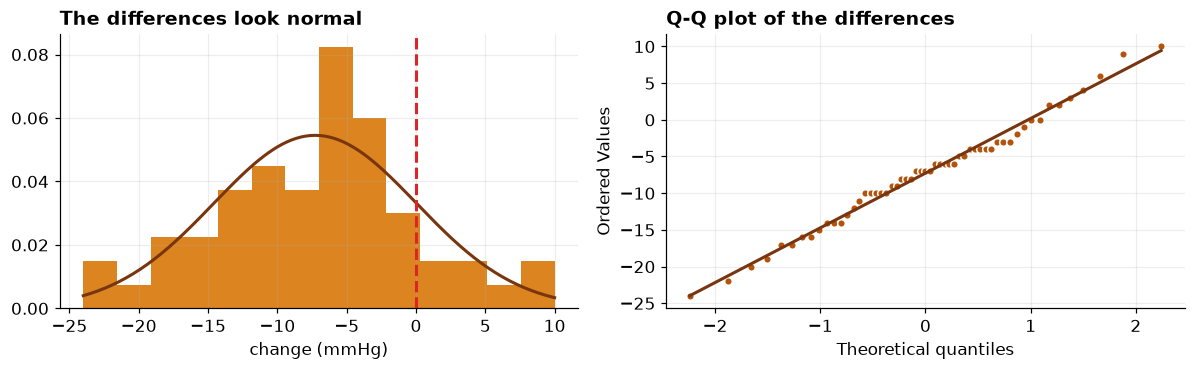

In [7]:
sw = stats.shapiro(change)
print(f"Shapiro-Wilk on the differences: W = {sw.statistic:.3f}, p = {sw.pvalue:.3f}  -> {'normal enough' if sw.pvalue>0.05 else 'not normal'}")
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].hist(change, bins=14, color=AMBER, alpha=0.9, density=True)
xs = np.linspace(change.min(), change.max(), 200)
ax[0].plot(xs, stats.norm.pdf(xs, change.mean(), change.std(ddof=1)), color=DARK, lw=2)
ax[0].axvline(0, color=RD, lw=2, ls="--"); ax[0].set_title("The differences look normal"); ax[0].set_xlabel("change (mmHg)")
stats.probplot(change, dist="norm", plot=ax[1])
ax[1].get_lines()[0].set(marker="o", markerfacecolor=GOLD, markeredgecolor="white", markersize=5)
ax[1].get_lines()[1].set(color=DARK, lw=2); ax[1].set_title("Q-Q plot of the differences")
plt.tight_layout(); plt.show()

## Step 8 &middot; Decide, and fix
The differences pass the normality check, so the paired t-test is valid. As a safety net we also run its rank-based twin, the **Wilcoxon signed-rank test**, which does not assume normal differences. If they disagreed we would trust the rank-based one; here they will agree.

## Step 9 &middot; Choose the test
- **Primary:** paired t-test on the before-after differences.
- **Robustness check:** Wilcoxon signed-rank test.
- **Reported alongside:** Cohen's d for paired data and the 95% confidence interval for the mean change.

## Step 10 &middot; Run the test and report fully
`scipy` runs the paired test with `ttest_rel`; `pingouin` adds the effect size, the confidence interval, and the power. We also run the (incorrect) independent-samples test on the same numbers, to see how much the pairing bought us.

In [8]:
t, p = stats.ttest_rel(after, before)
print(f"paired t-test:  t({len(df)-1}) = {t:.3f},  p = {p:.2e}")

res = pg.ttest(after, before, paired=True)
print("\npingouin paired t-test:")
print(res[["T","dof","alternative","power"]].round(3).to_string(index=False))
ci = res["CI95"].iloc[0]
dz = abs(change.mean())/change.std(ddof=1)      # Cohen's d_z: standardized by the SD of the differences (the paired effect size)
print(f"\nmean change: {change.mean():+.2f} mmHg")
print(f"95% CI for the mean change: [{ci[0]:.2f}, {ci[1]:.2f}] mmHg")
print(f"Cohen's d_z (paired) = {dz:.2f}  ({'small' if dz<0.5 else 'medium' if dz<0.8 else 'large'} effect)")

w, pw = stats.wilcoxon(after, before)
print(f"\nWilcoxon signed-rank (robustness): W = {w:.1f}, p = {pw:.2e}  -> same conclusion")

# what if we (wrongly) treated the two columns as independent groups?
ti, pi = stats.ttest_ind(after, before)
se_paired = change.std(ddof=1)/np.sqrt(len(df))
se_indep  = np.sqrt(before.var(ddof=1)/len(df) + after.var(ddof=1)/len(df))
print(f"\nfor contrast, the WRONG independent-samples test: t = {ti:.2f}, p = {pi:.2e}")
print(f"standard error, paired = {se_paired:.2f} mmHg  vs  independent = {se_indep:.2f} mmHg  ({se_indep/se_paired:.1f}x larger)")
print("pairing removes between-patient variability, so the paired test is far more precise.")

paired t-test:  t(54) = -7.372,  p = 1.03e-09

pingouin paired t-test:
     T  dof alternative  power
-7.372   54   two-sided  0.985

mean change: -7.27 mmHg
95% CI for the mean change: [-9.25, -5.29] mmHg
Cohen's d_z (paired) = 0.99  (large effect)

Wilcoxon signed-rank (robustness): W = 110.0, p = 8.13e-08  -> same conclusion

for contrast, the WRONG independent-samples test: t = -2.98, p = 3.60e-03
standard error, paired = 0.99 mmHg  vs  independent = 2.44 mmHg  (2.5x larger)
pairing removes between-patient variability, so the paired test is far more precise.


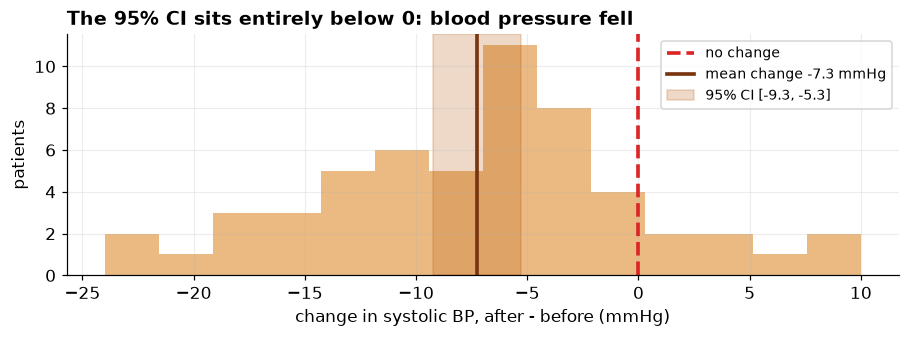

In [9]:
# Result in one picture: the mean change and its 95% CI against zero.
tcrit = stats.t.ppf(0.975, len(df)-1); se = change.std(ddof=1)/np.sqrt(len(df))
lo, hi = change.mean()-tcrit*se, change.mean()+tcrit*se
fig, ax = plt.subplots(figsize=(8.4, 3.2))
ax.hist(change, bins=14, color=AMBER, alpha=0.5)
ax.axvline(0, color=RD, lw=2.4, ls="--", label="no change")
ax.axvline(change.mean(), color=DARK, lw=2.4, label=f"mean change {change.mean():.1f} mmHg")
ax.axvspan(lo, hi, color=GOLD, alpha=0.22, label=f"95% CI [{lo:.1f}, {hi:.1f}]")
ax.set_title("The 95% CI sits entirely below 0: blood pressure fell")
ax.set_xlabel("change in systolic BP, after - before (mmHg)"); ax.set_ylabel("patients"); ax.legend(fontsize=9)
plt.tight_layout(); plt.show()

## Step 11 &middot; Estimate, do not just test
Blood pressure fell. The clinically useful question is by how much, and whether the plausible range clears the threshold anyone cares about.

In [10]:
# A percentile bootstrap: resample the data with replacement, recompute, repeat.
# Chapter 73 introduced this; it is how we get an interval when no formula exists.
def boot_ci(data, stat, B=10000, seed=11, ci=95):
    rng = np.random.default_rng(seed)
    data = np.asarray(data)
    reps = np.array([stat(rng.choice(data, size=len(data), replace=True)) for _ in range(B)])
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_pairs(a, b, stat, B=10000, seed=11, ci=95):
    """Bootstrap for two paired/related arrays: resample ROW indices together."""
    rng = np.random.default_rng(seed)
    a, b = np.asarray(a), np.asarray(b)
    idx = np.arange(len(a))
    reps = np.array([stat(a[i], b[i]) for i in
                     (rng.choice(idx, size=len(idx), replace=True) for _ in range(B))])
    reps = reps[np.isfinite(reps)]
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

def boot_ci_groups(groups, stat, B=10000, seed=11, ci=95):
    """Bootstrap for k independent groups: resample within each group."""
    rng = np.random.default_rng(seed)
    groups = [np.asarray(g) for g in groups]
    reps = []
    for _ in range(B):
        rs = [rng.choice(g, size=len(g), replace=True) for g in groups]
        v = stat(rs)
        if np.isfinite(v):
            reps.append(v)
    reps = np.array(reps)
    half = (100 - ci) / 2
    return np.percentile(reps, half), np.percentile(reps, 100 - half), reps

print(f"mean change            {change.mean():+.2f} mmHg   95% CI [{lo:+.2f}, {hi:+.2f}] mmHg")
print(f"margin of error        +/- {(hi-lo)/2:.2f} mmHg\n")

dz_lo, dz_hi, _ = boot_ci(change, lambda s: abs(s.mean()) / s.std(ddof=1))
print(f"Cohen's d_z            {dz:.2f}          95% CI [{dz_lo:.2f}, {dz_hi:.2f}]")

# The pairing gain rests on the before/after correlation, so give that an interval too.
r_pair = np.corrcoef(before, after)[0, 1]
rp_lo, rp_hi, _ = boot_ci_pairs(before, after, lambda a, b: np.corrcoef(a, b)[0, 1])
print(f"before/after correlation {r_pair:.2f}        95% CI [{rp_lo:.2f}, {rp_hi:.2f}]")

# A clinically anchored question the p-value cannot answer.
THRESH = -5.0
print(f"\nis the drop at least {abs(THRESH):.0f} mmHg? the interval runs to {hi:+.2f},")
print("so a drop smaller than 5 mmHg is not ruled out by these data.")

mean change            -7.27 mmHg   95% CI [-9.25, -5.29] mmHg
margin of error        +/- 1.98 mmHg



Cohen's d_z            0.99          95% CI [0.71, 1.39]


before/after correlation 0.85        95% CI [0.78, 0.90]

is the drop at least 5 mmHg? the interval runs to -5.29,
so a drop smaller than 5 mmHg is not ruled out by these data.


**What the interval changes.** The program is associated with a fall of about 7.3 mmHg, but the range consistent with the data runs from roughly 5.3 to 9.3. A cardiologist asked whether the drop clears a 5 mmHg clinical threshold gets a straight answer: probably, but the lower end sits right on it. That is a materially different conversation from "p is less than 0.001".

The before-and-after correlation of 0.85 also carries an interval, and it stays high throughout. That is what justifies the pairing: the design is buying real precision, not getting lucky in this sample.

## Step 12 &middot; A third variable that was sitting in the file
The dataset records each participant's `age`, which the analysis has ignored. Age is the classic confounder in cardiovascular work, so it is worth asking what it does here.

In [11]:
age = df.age.values.astype(float)
r_ac, p_ac = stats.pearsonr(age, change)
r_ab, p_ab = stats.pearsonr(age, before)
print(f"age vs baseline BP      r = {r_ab:+.3f}  p = {p_ab:.3f}")
print(f"age vs change in BP     r = {r_ac:+.3f}  p = {p_ac:.3f}\n")
older = change[age >= np.median(age)]; younger = change[age < np.median(age)]
print(f"older half  (age >= {np.median(age):.0f})  n = {len(older):2d}   mean change {older.mean():+.2f} mmHg")
print(f"younger half (age <  {np.median(age):.0f})  n = {len(younger):2d}   mean change {younger.mean():+.2f} mmHg")
tt_age = stats.ttest_ind(older, younger, equal_var=False)
print(f"difference between the two halves: {older.mean()-younger.mean():+.2f} mmHg, p = {tt_age.pvalue:.3f}")

age vs baseline BP      r = -0.078  p = 0.572
age vs change in BP     r = +0.266  p = 0.050

older half  (age >= 59)  n = 29   mean change -4.62 mmHg
younger half (age <  59)  n = 26   mean change -10.23 mmHg
difference between the two halves: +5.61 mmHg, p = 0.004


**This one did not come back quiet.** Age barely relates to baseline blood pressure here, but it does relate to how much blood pressure moved (r = +0.27, p = 0.05). The sign is easy to misread: change is negative, so a **positive** correlation means older participants dropped **less**. Splitting at the median age makes it plain. The younger half fell by 10.2 mmHg on average and the older half by 4.6, a gap of 5.6 mmHg (p = 0.004), which is comparable in size to the whole program effect.

**That is effect modification, not confounding, and the distinction matters.** A confounder would mean age produced the apparent drop and the program did nothing. What we have instead is a program that appears to work considerably better in younger participants. Nothing here is explained away; the headline is refined.

Two cautions come with it. First, this subgroup split was chosen after seeing the data, which is the trap Capstone 4 is built around. A median split found by looking is a hypothesis for the next study, not a finding from this one. Second, and more fundamentally, **no covariate you can measure fixes a missing control group.** The explanations that genuinely threaten this design, regression to the mean, placebo, and eight weeks of natural variation, are not columns in the file, and they would produce an age pattern too if older participants started closer to their natural baseline. That is the difference between adjusting for a confounder and having a comparison arm, and it is why the next step leads with the limitation rather than the result.

## Step 13 &middot; Interpret in plain language
Systolic blood pressure fell by about **7 mmHg** on average over the eight weeks. The paired test says a drop that size is far too large to be chance (p is about one in a billion), and the 95% confidence interval, roughly **5 to 9 mmHg lower**, stays entirely below zero. The effect is large (Cohen's d_z near 1.0). A sustained 5-to-10 mmHg drop in systolic BP is clinically meaningful, it measurably lowers cardiovascular risk, so this is not just a statistical result but a relevant one.

## Step 14 &middot; The limit that matters most
Here is the honest catch, and it is the whole reason single-arm before-after studies are treated with caution: **there is no control group.** The test proves blood pressure changed; it cannot prove the program caused the change. Several other explanations fit the same data.
- **Regression to the mean.** Patients were enrolled because their BP was high. Extreme readings tend to drift back toward average on their own, even with no treatment.
- **Natural change, season, and measurement.** Diet, weather, white-coat effect at the first visit, and a more relaxed second visit can all move BP.
- **Placebo and attention.** Being in a program changes behavior regardless of its active ingredients.
To attribute the drop to the program, you need a **control group** that is measured the same way but does not get the program, ideally a randomized trial. The paired t-test is the right test for *did it change*; it is the wrong tool for *did the program cause it*.

---
**From analysis to report.** The notebook carries the evidence: the paired plot, the normality check on the differences, the test, the effect size, and the interval. The written report turns it into a memo a clinical lead can read, leading with the result and, crucially, flagging the missing control group so no one over-claims causation. Automate the evidence; author the argument.